# Homework 5

Note: Our group, Kymanni and I, spent 4 hours working together on April 13 at 4:00 PM. We're not exactly sure what's going on with our other groupmate, Jaiden. (RS).

## 8.1-1

What is the smallest possible depth of a leaf in a decision tree for a comparison sort?

#### My answer:
The smallest possible leaf depth is
$$
n-1.
$$

#### My explanation:
A leaf corresponds to one completely determined ordering of the input. Along a root-to-leaf path, every comparison only tells us the relative order of the two elements that were compared. If a path has fewer than $n-1$ comparisons, then the graph whose vertices are the $n$ input elements and whose edges are the comparisons on that path has fewer than $n-1$ edges. So that graph is disconnected. That means there are at least two groups of elements that were never compared across groups.

If we swap those two groups while keeping the internal order inside each group the same, every comparison on the path gives the exact same result as before, because every comparison stayed inside one connected component. So the same leaf would be consistent with at least two different permutations, which is impossible for a correct comparison sort. Therefore, by contradiction, every leaf must have depth at least $n-1$.

For example, on an already sorted input, insertion sort can follow a path that just checks
$$
a_1<a_2,\;a_2<a_3,\;\ldots,\;a_{n-1}<a_n,
$$
which uses exactly $n-1$ comparisons and already certifies the ordering
$$
a_1<a_2<\cdots<a_n.
$$
So the smallest possible leaf depth is exactly $n-1$.

#### SymPy / Matplotlib check:

Remaining possible permutations for n=4 after consecutive comparisons:
depth 0: 24 possibilities
depth 1: 12 possibilities
depth 2: 4 possibilities
depth 3: 1 possibilities


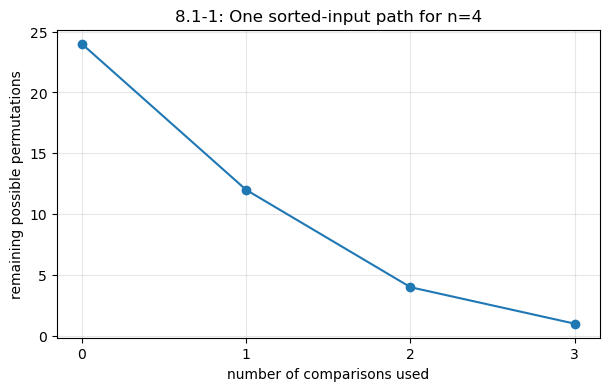

In [1]:
import itertools
import math
import matplotlib.pyplot as plt

# For n=4, count how many permutations are still possible
# after checking a1<a2, then a2<a3, then a3<a4.
perms = list(itertools.permutations([1, 2, 3, 4]))
counts = [len(perms)]
constraints = [
    lambda p: p[0] < p[1],
    lambda p: p[1] < p[2],
    lambda p: p[2] < p[3],
]
current = perms[:]
for cond in constraints:
    current = [p for p in current if cond(p)]
    counts.append(len(current))
print("Remaining possible permutations for n=4 after consecutive comparisons:")
for depth, count in enumerate(counts):
    print(f"depth {depth}: {count} possibilities")
xs = list(range(len(counts)))
plt.figure(figsize=(7, 4))
plt.plot(xs, counts, marker="o")
plt.xticks(xs)
plt.xlabel("number of comparisons used")
plt.ylabel("remaining possible permutations")
plt.title("8.1-1: One sorted-input path for n=4")
plt.grid(True, alpha=0.3)
plt.show()

The plot is just a small sanity check for $n=4$: after 3 consecutive comparisons, exactly 1 permutation remains, which matches the claim that depth $n-1$ can be enough.

## 8.2-2

Prove that `COUNTING-SORT` is stable.

#### My proof:
Stability means that if two elements have the same key and the first one appears earlier in the input, then it must also appear earlier in the output. In the textbook's `COUNTING-SORT(A,n,k)`, after lines 7-8, the array $C[i]$ stores the number of input elements less than or equal to $i$. So when we place a value $x=A[j]$, the position
$$
C[x]
$$
is the last open slot where a copy of $x$ should go. The important detail is that the final loop runs from
$$
j=n,\;n-1,\;\ldots,\;1.
$$
So suppose $A[i]=A[j]=x$ with $i<j$. The algorithm processes $A[j]$ first, places it into the last available slot for value $x$, and then decrements $C[x]$. Later, when the algorithm processes $A[i]$, it places it into the next slot to the left. Therefore, the earlier occurrence $A[i]$ ends up to the left of the later occurrence $A[j]$ in the output. Since this is true for every pair of equal keys, `COUNTING-SORT` is stable.

#### Wanted to see a Python check as well for myself:

In [2]:
# Stable counting sort on tagged values.
def counting_sort_stable_tagged(items, k):
    counts = [0] * (k + 1)
    for value, _ in items:
        counts[value] += 1
    for i in range(1, k + 1):
        counts[i] += counts[i - 1]
    output = [None] * len(items)
    for j in range(len(items) - 1, -1, -1):
        value, tag = items[j]
        output[counts[value] - 1] = (value, tag)
        counts[value] -= 1
    return output
tagged = [(2, "a"), (5, "b"), (3, "c"), (0, "d"), (2, "e"), (3, "f"), (0, "g"), (3, "h")]
result = counting_sort_stable_tagged(tagged, 5)
print("input :", tagged)
print("output:", result)
print("Order of the 2s in output:", [tag for value, tag in result if value == 2])
print("Order of the 3s in output:", [tag for value, tag in result if value == 3])

input : [(2, 'a'), (5, 'b'), (3, 'c'), (0, 'd'), (2, 'e'), (3, 'f'), (0, 'g'), (3, 'h')]
output: [(0, 'd'), (0, 'g'), (2, 'a'), (2, 'e'), (3, 'c'), (3, 'f'), (3, 'h'), (5, 'b')]
Order of the 2s in output: ['a', 'e']
Order of the 3s in output: ['c', 'f', 'h']


The tagged duplicates keep their original order in the output, which is exactly what stability means.

## 8.2-3

Suppose line 11 is rewritten as `for j = 1 to n`. Show it still works properly, but is not stable. Then rewrite the pseudocode so it is stable and writes equal keys in increasing-index order.

#### My explanation:
If we keep lines 1-10 exactly as in the textbook and only change line 11 to run forward, then the loop becomes
```text
11 for j = 1 to n
12     B[C[A[j]]] = A[j]
13     C[A[j]] = C[A[j]] - 1
```
After lines 7-8, $C[x]$ still means “the number of elements less than or equal to $x$.” So the block of output positions reserved for value $x$ is still correct, and each time we place an $x$, line 13 moves us one slot left inside that block. Because of that, the output is still sorted correctly. But it is not stable. If $A[i]=A[j]=x$ with $i<j$, then the forward loop processes $A[i]$ first and sends it to the rightmost currently open slot for value $x$. Later, $A[j]$ gets placed into a slot to the left of it. So equal keys get reversed. A concrete example is
$$
[(2,a),(2,b),(1,c)].
$$
The forward version outputs
$$
[(1,c),(2,b),(2,a)],
$$
which is sorted, but the two 2s are reversed, so it is not stable. To make a forward loop stable, we should change the meaning of $C$. Instead of storing how many elements are less than or equal to each key, we want $C[i]$ to store how many elements are strictly less than $i$. Then a forward scan can place each value into the next open slot for that key.

#### Stable left-to-right pseudocode:
```text
COUNTING-SORT-STABLE-FORWARD(A, n, k)
1  let B[1 : n] and C[0 : k] be new arrays
2  for i = 0 to k
3      C[i] = 0
4  for j = 1 to n
5      C[A[j]] = C[A[j]] + 1
6  for i = 1 to k
7      C[i] = C[i] + C[i-1]
8  for i = k downto 1
9      C[i] = C[i-1]
10 C[0] = 0
11 for j = 1 to n
12     B[C[A[j]] + 1] = A[j]
13     C[A[j]] = C[A[j]] + 1
14 return B
```

After line 10, $C[x]$ is the number of elements strictly less than $x$, so line 12 writes the current copy of $x$ into the leftmost open slot for that key. Then line 13 moves the pointer one step to the right. Since we scan $j$ in increasing order, equal keys are written in increasing-index order, and the algorithm is stable. In the Python check below, the lists use 0-based indexing instead of the textbook's 1-based indexing. So textbook line 12,
$$
B[C[A[j]]+1] = A[j],
$$
appears in Python as `output[counts[value]] = (value, tag)`. Likewise, the forward-but-unstable textbook placement `B[C[A[j]]] = A[j]` appears as `output[counts[value]-1] = (value, tag)`.

#### Python / Matplotlib check:

input   : [(2, 'a'), (2, 'b'), (1, 'c'), (2, 'd'), (1, 'e')]
forward : [(1, 'e'), (1, 'c'), (2, 'd'), (2, 'b'), (2, 'a')]
stable  : [(1, 'c'), (1, 'e'), (2, 'a'), (2, 'b'), (2, 'd')]


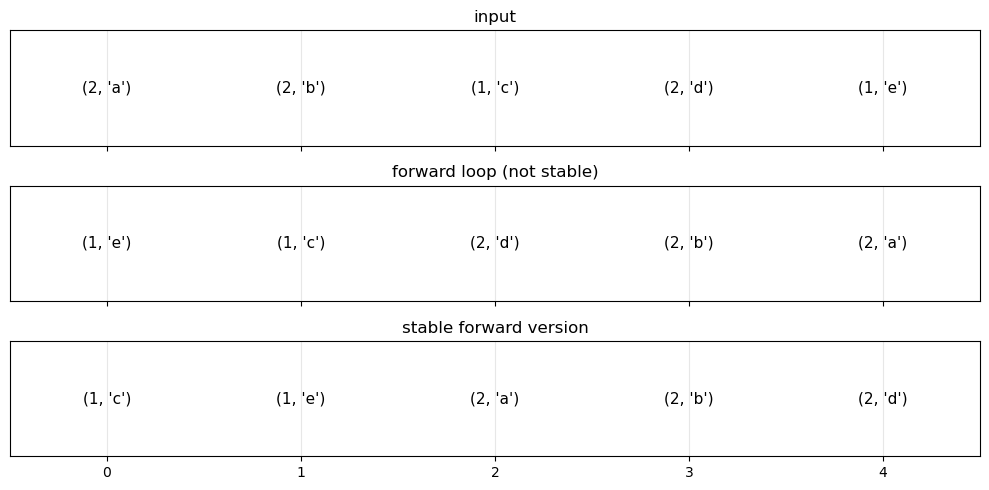

In [3]:
import matplotlib.pyplot as plt

# Forward scan with the textbook cumulative counts: sorted, but not stable.
def counting_sort_forward_unstable(items, k):
    counts = [0] * (k + 1)
    for value, _ in items:
        counts[value] += 1
    for i in range(1, k + 1):
        counts[i] += counts[i - 1]
    output = [None] * len(items)
    for j in range(len(items)):
        value, tag = items[j]
        output[counts[value] - 1] = (value, tag)
        counts[value] -= 1
    return output

# Forward scan after shifting counts so counts[x] means "# of keys < x".
def counting_sort_forward_stable(items, k):
    counts = [0] * (k + 1)
    for value, _ in items:
        counts[value] += 1
    for i in range(1, k + 1):
        counts[i] += counts[i - 1]
    for i in range(k, 0, -1):
        counts[i] = counts[i - 1]
    counts[0] = 0
    output = [None] * len(items)
    for j in range(len(items)):
        value, tag = items[j]
        output[counts[value]] = (value, tag)
        counts[value] += 1
    return output

tagged = [(2, "a"), (2, "b"), (1, "c"), (2, "d"), (1, "e")]
bad = counting_sort_forward_unstable(tagged, 2)
good = counting_sort_forward_stable(tagged, 2)

print("input   :", tagged)
print("forward :", bad)
print("stable  :", good)

fig, ax = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
rows = [tagged, bad, good]
titles = ["input", "forward loop (not stable)", "stable forward version"]
for r, (row, title) in enumerate(zip(rows, titles)):
    ax[r].set_title(title)
    ax[r].set_xlim(-0.5, len(row) - 0.5)
    ax[r].set_ylim(-0.5, 0.5)
    ax[r].set_yticks([])
    ax[r].grid(True, axis="x", alpha=0.3)
    for i, item in enumerate(row):
        ax[r].text(i, 0, str(item), ha="center", va="center", fontsize=11)
plt.tight_layout()
plt.show()

The middle row is sorted but reverses equal keys, while the bottom row is both sorted and stable.

## 8.2-6

Describe an algorithm that preprocesses $n$ integers in the range $0$ to $k$ so that any query asking how many fall in a range $[a:b]$ can be answered in $O(1)$ time, using $\Theta(n+k)$ preprocessing.

#### My algorithm:
We use the same counting idea as in counting sort.

1. Create an array $C[0:k]$ and initialize it to $0$.
2. For each input value $x$, increment $C[x]$.
3. Replace $C$ by its prefix sums, so that after preprocessing,
   $$
   C[i]=\text{number of input elements }\le i.
   $$

Now answer a query $[a:b]$ in constant time by
$$
\#([a:b])=
\begin{cases}
C[b], & a=0,\\[4pt]
C[b]-C[a-1], & a>0.
\end{cases}
$$

#### Why it works:
$C[b]$ counts how many elements are at most $b$. If $a>0$, then $C[a-1]$ counts how many are strictly less than $a$. Subtracting gives exactly the number in the interval $[a:b]$.

#### Running time:
Building the frequency array takes $\Theta(n)$, and converting it to prefix sums takes $\Theta(k)$. So preprocessing is $\Theta(n+k)$. Each query uses only one subtraction (or none when $a=0$), so each query is $O(1)$.

#### Python / Matplotlib check:

array: [2, 5, 3, 0, 2, 3, 0, 3]
counts: [2, 0, 2, 3, 0, 1]
prefix: [2, 2, 4, 7, 7, 8]
query [0:0] -> fast=2, brute=2
query [0:3] -> fast=7, brute=7
query [2:3] -> fast=5, brute=5
query [4:5] -> fast=1, brute=1


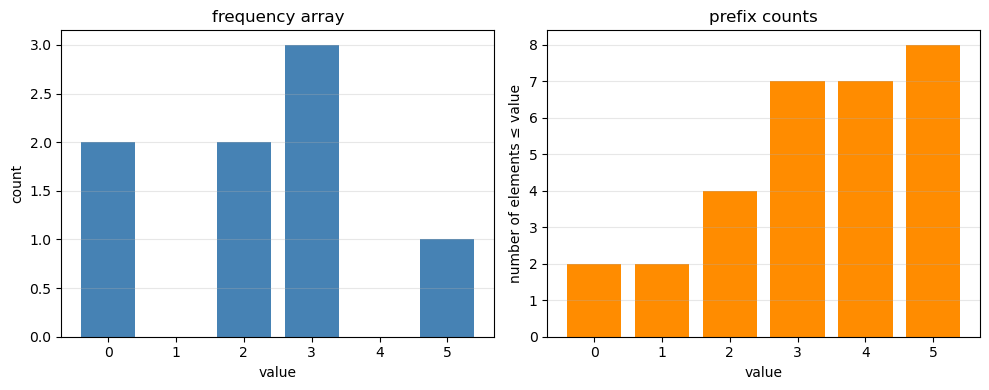

In [4]:
import matplotlib.pyplot as plt

A = [2, 5, 3, 0, 2, 3, 0, 3]
k = 5

counts = [0] * (k + 1)
for x in A:
    counts[x] += 1
prefix = counts[:]
for i in range(1, k + 1):
    prefix[i] += prefix[i - 1]

def range_count(a, b):
    return prefix[b] if a == 0 else prefix[b] - prefix[a - 1]

queries = [(0, 0), (0, 3), (2, 3), (4, 5)]
print("array:", A)
print("counts:", counts)
print("prefix:", prefix)
for a, b in queries:
    brute = sum(a <= x <= b for x in A)
    fast = range_count(a, b)
    print(f"query [{a}:{b}] -> fast={fast}, brute={brute}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
xs = list(range(k + 1))
ax[0].bar(xs, counts, color="steelblue")
ax[0].set_title("frequency array")
ax[0].set_xlabel("value")
ax[0].set_ylabel("count")
ax[1].bar(xs, prefix, color="darkorange")
ax[1].set_title("prefix counts")
ax[1].set_xlabel("value")
ax[1].set_ylabel("number of elements ≤ value")
for axis in ax:
    axis.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The output checks the formula against brute force, and the two plots show exactly what the preprocessing is storing.

## 9.1-1

Show that the second smallest of $n$ elements can be found with
$$
n+\lceil \lg n\rceil-2
$$
comparisons in the worst case.

#### My proof:
We use a tournament (I like to think similiar in nature to merge sort but without the O(n) work time when merging) idea. First, find the minimum by comparing elements in pairs and letting the smaller one advance. This takes exactly
$$
n-1
$$
comparisons, because every comparison eliminates exactly one element from being the minimum. While doing that, keep track of the elements that lose directly to the eventual minimum. The second smallest element must be one of these losers, because any element that lost to something other than the minimum cannot be the second smallest. So the whole problem reduces to this:
1. find the minimum,
2. look only at the elements that lost directly to it,
3. find the minimum among those.

How many elements can lose directly to the minimum? At most $\lceil \lg n\rceil$. Each time the minimum wins a comparison in the tournament, the number of elements in the block it has beaten at least doubles. So after $t$ wins, it has beaten at least $2^t$ elements counting itself. Since there are only $n$ elements total, we must have
$$
2^t\le 2^{\lceil \lg n\rceil},
$$
and therefore
$$
t\le \lceil \lg n\rceil.
$$

Now find the smallest among those at most $\lceil \lg n\rceil$ losers. That takes at most
$$
\lceil \lg n\rceil-1
$$
comparisons. Therefore, the total number of comparisons is
$$
(n-1)+(\lceil \lg n\rceil-1)=n+\lceil \lg n\rceil-2.
$$
So the second smallest can be found with at most $n+\lceil \lg n\rceil-2$ comparisons in the worst case.

#### Python / Matplotlib check:

n, comparisons used, bound, direct losers to min
2 1 1 1
3 2 3 1
4 4 4 2
5 4 6 1
6 6 7 2
7 7 8 2
8 9 9 3
9 8 11 1
10 10 12 2
11 11 13 2


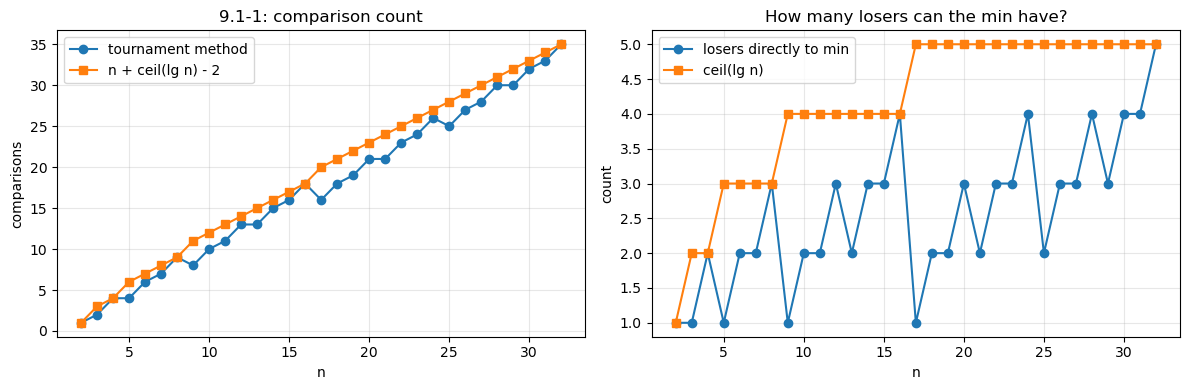

In [5]:
import math
import matplotlib.pyplot as plt

def second_smallest_tournament(arr):
    players = [(x, []) for x in arr]
    comps = 0
    while len(players) > 1:
        nxt = []
        i = 0
        while i + 1 < len(players):
            (x, lost_x), (y, lost_y) = players[i], players[i + 1]
            comps += 1
            if x < y:
                nxt.append((x, lost_x + [y]))
            else:
                nxt.append((y, lost_y + [x]))
            i += 2
        if i < len(players):
            nxt.append(players[i])
        players = nxt
    minimum, losers = players[0]
    second = losers[0]
    for z in losers[1:]:
        comps += 1
        if z < second:
            second = z
    return minimum, second, comps, len(losers)

ns = list(range(2, 33))
counts = []
bounds = []
loser_counts = []

for n in ns:
    arr = list(range(n, 0, -1))
    _, _, comps, loser_count = second_smallest_tournament(arr)
    counts.append(comps)
    bounds.append(n + math.ceil(math.log2(n)) - 2)
    loser_counts.append(loser_count)

print("n, comparisons used, bound, direct losers to min")
for n, c, b, t in zip(ns[:10], counts[:10], bounds[:10], loser_counts[:10]):
    print(n, c, b, t)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ns, counts, marker="o", label="tournament method")
ax[0].plot(ns, bounds, marker="s", label="n + ceil(lg n) - 2")
ax[0].set_title("9.1-1: comparison count")
ax[0].set_xlabel("n")
ax[0].set_ylabel("comparisons")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(ns, loser_counts, marker="o", label="losers directly to min")
ax[1].plot(ns, [math.ceil(math.log2(n)) for n in ns], marker="s", label="ceil(lg n)")
ax[1].set_title("How many losers can the min have?")
ax[1].set_xlabel("n")
ax[1].set_ylabel("count")
ax[1].grid(True, alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.show()

The left plot shows the comparison count of the tournament method staying within the claimed bound, and the right plot shows why the extra term is only about $\lceil \lg n\rceil$: the minimum is compared directly against only that many elements.